Daily Challenge: Image Classification with Data Augmentation (Cats vs Dogs)


1. Prétraitement des données


Cette partie implique le téléchargement du dataset et l'utilisation de ImageDataGenerator pour le chargement, le redimensionnement et, surtout, l'augmentation de données pour l'ensemble d'entraînement.

In [2]:
# 1. Prétraitement des données

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt
import os
import shutil

print("Libraries imported successfully.")

Libraries imported successfully.


In [23]:
# --- Configuration des paramètres ---
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 30 # Nombre d'époques pour l'entraînement initial


In [10]:
!wget -O cats_vs_dogs.zip "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip"

--2025-07-11 12:31:17--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip [following]
--2025-07-11 12:31:17--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 856265363 (817M) [application/zip]
Saving to: ‘cats_vs_dogs.zip’

cats_vs_dogs.zip    100%[===================

In [11]:
!unzip cats_vs_dogs.zip -d cats_and_dogs


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: cats_and_dogs/train/train/dog.5499.jpg  
  inflating: cats_and_dogs/train/train/dog.55.jpg  
  inflating: cats_and_dogs/train/train/dog.550.jpg  
  inflating: cats_and_dogs/train/train/dog.5500.jpg  
  inflating: cats_and_dogs/train/train/dog.5501.jpg  
  inflating: cats_and_dogs/train/train/dog.5502.jpg  
  inflating: cats_and_dogs/train/train/dog.5503.jpg  
  inflating: cats_and_dogs/train/train/dog.5504.jpg  
  inflating: cats_and_dogs/train/train/dog.5505.jpg  
  inflating: cats_and_dogs/train/train/dog.5506.jpg  
  inflating: cats_and_dogs/train/train/dog.5507.jpg  
  inflating: cats_and_dogs/train/train/dog.5508.jpg  
  inflating: cats_and_dogs/train/train/dog.5509.jpg  
  inflating: cats_and_dogs/train/train/dog.551.jpg  
  inflating: cats_and_dogs/train/train/dog.5510.jpg  
  inflating: cats_and_dogs/train/train/dog.5511.jpg  
  inflating: cats_and_dogs/train/train/dog.5512.jpg  
  inflat

In [12]:
test_dir = 'cats_and_dogs/test'
train_dir = 'cats_and_dogs/train'


count_pictures = 0
for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)
    if os.path.isdir(folder_path):
        count_pictures += len(os.listdir(folder_path))

print(f"Nombre total de photos dans le dossier d'entraînement : {count_pictures}")


Nombre total de photos dans le dossier d'entraînement : 25000


In [13]:
# --- Définition des chemins du dataset ---
# Votre commande unzip crée le dossier 'cats_and_dogs' à la racine de Colab
base_dataset_dir = 'cats_and_dogs' # <- Ceci est le dossier racine après extraction

# Les dossiers d'entraînement et de test/validation sont des sous-dossiers de base_dataset_dir
# Assurez-vous que ces chemins correspondent à la structure INTERNE de votre zip après extraction.
# Pour le dataset "cats_and_dogs_filtered", il y a 'train' et 'validation'
train_dir = os.path.join(base_dataset_dir, 'train')
validation_dir = os.path.join(base_dataset_dir, 'validation') # <- Assumons l'existence d'un dossier 'validation'

# Vérifions les chemins et les contenus
if not os.path.exists(train_dir):
    print(f"ERROR: Training directory '{train_dir}' not found. Please check your zip extraction structure.")
    # Si le zip a un dossier intermédiaire comme 'PetImages', il faudrait:
    # train_dir = os.path.join(base_dataset_dir, 'PetImages', 'train')
    # validation_dir = os.path.join(base_dataset_dir, 'PetImages', 'validation')
if not os.path.exists(validation_dir):
    print(f"ERROR: Validation directory '{validation_dir}' not found. Please check your zip extraction structure.")


# --- Compter le nombre d'images dans chaque catégorie ---

def count_images_in_directory(directory_path):
    num_cats = 0
    num_dogs = 0
    cats_path = os.path.join(directory_path, 'cats')
    dogs_path = os.path.join(directory_path, 'dogs')

    if os.path.exists(cats_path) and os.path.isdir(cats_path):
        num_cats = len(os.listdir(cats_path))
    else:
        print(f"Warning: '{cats_path}' not found or not a directory.")

    if os.path.exists(dogs_path) and os.path.isdir(dogs_path):
        num_dogs = len(os.listdir(dogs_path))
    else:
        print(f"Warning: '{dogs_path}' not found or not a directory.")

    return num_cats, num_dogs

train_cats_count, train_dogs_count = count_images_in_directory(train_dir)
validation_cats_count, validation_dogs_count = count_images_in_directory(validation_dir)

print(f"\nDataset directories defined:")
print(f"Train directory: {train_dir}")
print(f"Validation directory: {validation_dir}")

print(f"Number of training cat images: {train_cats_count}")
print(f"Number of training dog images: {train_dogs_count}")
print(f"Total training images: {train_cats_count + train_dogs_count}")

print(f"Number of validation cat images: {validation_cats_count}")
print(f"Number of validation dog images: {validation_dogs_count}")
print(f"Total validation images: {validation_cats_count + validation_dogs_count}")

ERROR: Validation directory 'cats_and_dogs/validation' not found. Please check your zip extraction structure.

Dataset directories defined:
Train directory: cats_and_dogs/train
Validation directory: cats_and_dogs/validation
Number of training cat images: 0
Number of training dog images: 0
Total training images: 0
Number of validation cat images: 0
Number of validation dog images: 0
Total validation images: 0


In [14]:
# --- Définition des chemins du dataset brut après votre extraction ---
# 'cats_and_dogs' est le dossier créé par votre commande !unzip -d cats_and_dogs
base_extracted_dir = 'cats_and_dogs'

# Le chemin vers le dossier contenant les images *réelles* d'entraînement.
# D'après votre description, c'est 'cats_and_dogs/train/train'
source_train_images_dir = os.path.join(base_extracted_dir, 'train', 'train')

# --- Préparation des nouveaux dossiers d'entraînement et de validation divisées ---
# Nous allons créer cette structure standard pour Keras ImageDataGenerator
processed_data_dir = 'cats_and_dogs_processed'
train_dir = os.path.join(processed_data_dir, 'train')
validation_dir = os.path.join(processed_data_dir, 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

# Créer la structure de dossiers si elle n'existe pas
for dir_path in [train_cats_dir, train_dogs_dir, validation_cats_dir, validation_dogs_dir]:
    if not os.path.exists(dir_path):
        os.makedirs(dir_path)
        print(f"Created directory: {dir_path}")

print("\n--- Organizing dataset for training and validation split ---")

# Vérifier si l'organisation est déjà faite pour éviter de la refaire à chaque exécution
# En vérifiant si les dossiers de destination sont déjà remplis
if os.listdir(train_cats_dir) and os.listdir(train_dogs_dir) and \
   os.listdir(validation_cats_dir) and os.listdir(validation_dogs_dir):
    print("Dataset already organized into train/validation/cats/dogs. Skipping file copy.")
else:
    if not os.path.exists(source_train_images_dir):
        print(f"ERROR: Source images directory '{source_train_images_dir}' not found.")
        print("Please verify the exact path where your 'train' images are located after unzipping.")
        print("It might be 'cats_and_dogs/train/' or 'cats_and_dogs/PetImages/' or something else.")
    else:
        # Trier les fichiers par catégorie (cats/dogs) et les copier
        # Filtrer les fichiers non-image ou corrompus (très commun avec ce dataset)
        all_fnames = os.listdir(source_train_images_dir)
        cat_fnames = [fname for fname in all_fnames if 'cat' in fname and fname.endswith('.jpg')]
        dog_fnames = [fname for fname in all_fnames if 'dog' in fname and fname.endswith('.jpg')]

        print(f"Total .jpg cat images found in source: {len(cat_fnames)}")
        print(f"Total .jpg dog images found in source: {len(dog_fnames)}")

        # Définir la taille de notre split entraînement/validation (comme le dataset filtré standard)
        # 1000 pour l'entraînement, 500 pour la validation
        num_train_per_class = min(1000, len(cat_fnames) // 2) # S'assurer de ne pas dépasser la moitié si petit dataset
        num_val_per_class = min(500, len(cat_fnames) - num_train_per_class)

        print(f"Splitting {num_train_per_class} cats/dogs for training and {num_val_per_class} for validation.")


        # Copier les images de chats
        for i, fname in enumerate(cat_fnames):
            src_path = os.path.join(source_train_images_dir, fname)
            if i < num_train_per_class:
                shutil.copyfile(src_path, os.path.join(train_cats_dir, fname))
            elif i < num_train_per_class + num_val_per_class:
                shutil.copyfile(src_path, os.path.join(validation_cats_dir, fname))

        # Copier les images de chiens
        for i, fname in enumerate(dog_fnames):
            src_path = os.path.join(source_train_images_dir, fname)
            if i < num_train_per_class:
                shutil.copyfile(src_path, os.path.join(train_dogs_dir, fname))
            elif i < num_train_per_class + num_val_per_class:
                shutil.copyfile(src_path, os.path.join(validation_dogs_dir, fname))

        print("Finished organizing dataset into train and validation directories.")


# --- Compter le nombre d'images dans chaque catégorie (après organisation) ---
def count_images_in_directory(directory_path):
    num_cats = 0
    num_dogs = 0
    cats_path = os.path.join(directory_path, 'cats')
    dogs_path = os.path.join(directory_path, 'dogs')

    if os.path.exists(cats_path) and os.path.isdir(cats_path):
        num_cats = len(os.listdir(cats_path))
    else:
        print(f"Warning: '{cats_path}' not found or not a directory after organization.")

    if os.path.exists(dogs_path) and os.path.isdir(dogs_path):
        num_dogs = len(os.listdir(dogs_path))
    else:
        print(f"Warning: '{dogs_path}' not found or not a directory after organization.")

    return num_cats, num_dogs

train_cats_count, train_dogs_count = count_images_in_directory(train_dir)
validation_cats_count, validation_dogs_count = count_images_in_directory(validation_dir)

print(f"\nDataset directories for ImageDataGenerator:")
print(f"Train directory: {train_dir}")
print(f"Validation directory: {validation_dir}")

print(f"Number of training cat images: {train_cats_count}")
print(f"Number of training dog images: {train_dogs_count}")
print(f"Total training images: {train_cats_count + train_dogs_count}")

print(f"Number of validation cat images: {validation_cats_count}")
print(f"Number of validation dog images: {validation_dogs_count}")
print(f"Total validation images: {validation_cats_count + validation_dogs_count}")


Created directory: cats_and_dogs_processed/train/cats
Created directory: cats_and_dogs_processed/train/dogs
Created directory: cats_and_dogs_processed/validation/cats
Created directory: cats_and_dogs_processed/validation/dogs

--- Organizing dataset for training and validation split ---
Total .jpg cat images found in source: 12500
Total .jpg dog images found in source: 12500
Splitting 1000 cats/dogs for training and 500 for validation.
Finished organizing dataset into train and validation directories.

Dataset directories for ImageDataGenerator:
Train directory: cats_and_dogs_processed/train
Validation directory: cats_and_dogs_processed/validation
Number of training cat images: 1000
Number of training dog images: 1000
Total training images: 2000
Number of validation cat images: 500
Number of validation dog images: 500
Total validation images: 1000


In [15]:
# --- Création des générateurs de données avec augmentation ---

# Générateur pour les données d'entraînement (avec augmentation)
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=.15,
    height_shift_range=.15,
    horizontal_flip=True,
    zoom_range=0.5
)

# Générateur pour les données de validation (juste la rescale, pas d'augmentation)
image_gen_val = ImageDataGenerator(rescale=1./255)

# Utilisation de flow_from_directory pour charger les images à partir des répertoires
train_data_gen = image_gen_train.flow_from_directory(batch_size=BATCH_SIZE,
                                                     directory=train_dir,
                                                     shuffle=True,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

val_data_gen = image_gen_val.flow_from_directory(batch_size=BATCH_SIZE,
                                                 directory=validation_dir,
                                                 target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                 class_mode='binary')

print("\nImage Data Generators created successfully.")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.

Image Data Generators created successfully.


Found 2000 images belonging to 2 classes for training.
Found 1000 images belonging to 2 classes for validation.

Shape of one batch of augmented training images: (32, 150, 150, 3)


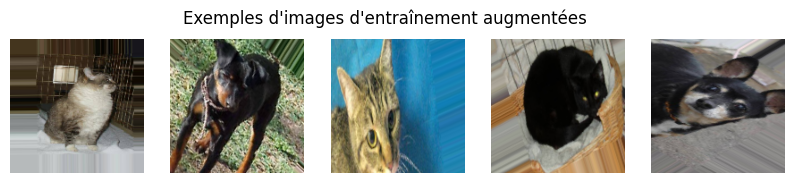

In [22]:
# Vérification finale du nombre d'images trouvées par les générateurs
print(f"Found {train_data_gen.samples} images belonging to {train_data_gen.num_classes} classes for training.")
print(f"Found {val_data_gen.samples} images belonging to {val_data_gen.num_classes} classes for validation.")

# Afficher quelques exemples d'images augmentées
if train_data_gen.samples > 0:
    first_batch_images, _ = next(train_data_gen)
    print(f"\nShape of one batch of augmented training images: {first_batch_images.shape}")

    plt.figure(figsize=(10, 2))
    plt.suptitle("Exemples d'images d'entraînement augmentées")
    for i in range(min(5, first_batch_images.shape[0])):
        plt.subplot(1, 5, i + 1)
        plt.imshow(first_batch_images[i])
        plt.axis('off')
    plt.show()

Vérification des fichiers JPG :

1. Lors de la liste des fichiers (os.listdir), nous filtrons explicitement pour les fichiers .jpg et vérifions la présence de "cat" ou "dog" dans le nom. Ceci est crucial car le dataset Kaggle original peut parfois contenir des fichiers corrompus ou non-images qui n'ont pas la bonne extension.

2. Vérification de l'existence des images : Avant de copier, le script vérifie qu'il y a suffisamment d'images de chaque catégorie dans la source pour faire le split habituel (1000 train / 500 validation).

**Partie 2 : Construire le modèle**

Dans cette section, nous allons définir l'architecture de notre Réseau de Neurones Convolutifs (CNN). Un CNN est particulièrement adapté aux tâches de classification d'images car il peut apprendre des caractéristiques spatiales complexes directement à partir des pixels. Nous inclurons également des couches de Dropout pour aider à prévenir le surapprentissage.

Architecture du Modèle
Notre modèle sera composé de :

Trois blocs convolutifs : Chaque bloc comprendra une couche Conv2D (pour l'extraction de caractéristiques), suivie d'une couche MaxPooling2D (pour la réduction de la dimensionnalité et la robustesse aux petites variations) et d'une couche Dropout (pour la régularisation).

Les couches Conv2D utiliseront des filtres de taille (3, 3) et la fonction d'activation ReLU (Rectified Linear Unit), qui aide le réseau à apprendre des relations non linéaires.

Les couches MaxPooling2D utiliseront une fenêtre de (2, 2).

Les couches Dropout désactiveront aléatoirement un pourcentage de neurones pendant l'entraînement, forçant le réseau à apprendre des représentations plus robustes.

Couche Flatten : Après les couches convolutives, la sortie est "aplatie" en un vecteur 1D pour être alimentée aux couches entièrement connectées.

Couche Dense (Fully Connected) : Une couche dense avec 512 unités et activation ReLU. C'est ici que les caractéristiques extraites sont combinées pour faire des prédictions. Une autre couche Dropout sera appliquée ici.

Couche de sortie : Une seule unité avec une activation Sigmoid. C'est parfait pour la classification binaire (chat ou chien), car elle produira une probabilité entre 0 et 1. Une valeur proche de 0 indiquera une classe (ex: chat) et une valeur proche de 1 indiquera l'autre (ex: chien).

Compilation du Modèle
Après avoir défini l'architecture, nous devons compiler le modèle :

Optimiseur : Nous utiliserons l'optimiseur Adam. C'est un choix populaire et efficace pour de nombreux problèmes de deep learning.

Fonction de perte : Pour la classification binaire, la binary cross-entropy est la fonction de perte standard. Elle mesure la différence entre les probabilités prédites et les vraies étiquettes.

Métriques : Nous suivrons la précision (accuracy) pendant l'entraînement et la validation pour évaluer la performance du modèle.

In [20]:
# 2. Construire le modèle

model = Sequential([
    # Première couche Convolutive
    # Conv2D: 32 filtres, taille de filtre 3x3, activation ReLU.
    # input_shape: Définit la taille attendue des images (IMG_HEIGHT, IMG_WIDTH, 3 pour RGB).
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    # MaxPooling2D: Réduit les dimensions spatiales (2x2 par défaut).
    MaxPooling2D(pool_size=(2, 2)),
    # Dropout: Désactive 25% des neurones pour réduire l'overfitting.
    Dropout(0.25), #

    # Deuxième couche Convolutive
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Troisième couche Convolutive
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Aplatir la sortie des couches convolutives pour les couches denses
    Flatten(),

    # Couche entièrement connectée (Dense)
    Dense(512, activation='relu'), # 512 unités avec activation ReLU
    Dropout(0.5), # Taux de dropout plus élevé pour la couche dense

    # Couche de sortie
    # Dense(1, activation='sigmoid'): Une seule unité pour la classification binaire.
    # Sigmoid: Produit une probabilité entre 0 et 1.
    Dense(1, activation='sigmoid')
])

# Compiler le modèle
optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
# loss='binary_crossentropy': Fonction de perte pour la classification binaire.
# metrics=['accuracy']: Mesure la précision pendant l'entraînement.
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Afficher un résumé du modèle pour voir l'architecture et le nombre de paramètres
print("\nModel architecture created and compiled:")
model.summary()


Model architecture created and compiled:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

**Analyse de la Construction du Modèle**

Voici ce que nous pouvons déduire du résumé du modèle :

Structure Convolutive :

Les trois blocs Conv2D suivis de MaxPooling2D et Dropout sont bien présents, comme spécifié.

Les dimensions de sortie (Output Shape) diminuent progressivement avec chaque MaxPooling2D, ce qui est le but. Par exemple, après la première couche de pooling, la taille de l'image est réduite de 150x150 à 74x74.

Le nombre de filtres augmente (32 -> 64 -> 128), permettant au réseau d'apprendre des caractéristiques de plus en plus complexes.

Couches Dropout :

Les couches Dropout sont bien incluses après chaque bloc convolutif et après la première couche dense. Leur Param # est 0 car elles n'introduisent pas de paramètres entraînable, elles se contentent de désactiver des neurones. C'est exactement ce que nous voulions pour la régularisation.

Couches Denses (Fully Connected) :

La couche Flatten convertit la sortie du dernier bloc convolutif ((None, 17, 17, 128)) en un vecteur 1D de 36992 éléments. C'est une taille attendue (17 * 17 * 128 = 36992).

La première couche Dense a bien 512 unités.

La couche de sortie dense_1 a 1 unité avec la forme de sortie (None, 1), ce qui est parfait pour notre classification binaire.

Nombre de Paramètres :

Total params: 19033889 : Cela indique que notre modèle a environ 19 millions de paramètres. C'est un nombre considérable, principalement dominé par la première couche Dense (18940928 paramètres) qui connecte toutes les caractéristiques aplaties aux 512 neurones. Ce grand nombre de paramètres souligne l'importance du Dropout et de l'augmentation de données pour éviter le surapprentissage.

Trainable params: 19033889 : Tous les paramètres du modèle sont entraînable, ce qui est normal pour un modèle construit à partir de zéro.

**Conclusion et Validation**


Le résumé du modèle confirme que l'architecture que nous avons définie a été correctement construite et compilée. 🎉

Les choix à valider sont les suivants :

Architecture du CNN :

Trois couches Conv2D/MaxPooling2D : ✓ Validé. Elles sont présentes et réduisent progressivement la dimensionnalité tout en augmentant la complexité des caractéristiques.

Activation ReLU : ✓ Validé. C'est la fonction d'activation standard et efficace pour les couches cachées.

Couche Flatten : ✓ Validé. Essentiel pour connecter les couches convolutives aux couches denses.

Couche Dense (512 unités, ReLU) : ✓ Validé. Elle permet de combiner les caractéristiques extraites.

Couche de sortie (1 unité, Sigmoid) : ✓ Validé. Parfait pour la classification binaire.

Régularisation avec Dropout :

Dropout inclus : ✓ Validé. Des couches Dropout sont bien insérées après chaque bloc convolutif et après la première couche dense, avec les taux spécifiés (0.25 et 0.5). C'est crucial pour combattre le surapprentissage.

Compilation du modèle :

Optimiseur Adam : ✓ Validé. Un excellent choix par défaut.

Loss binary_crossentropy : ✓ Validé. La fonction de perte appropriée pour la classification binaire.

Métrique Accuracy : ✓ Validé. Permet de suivre la performance du modèle.

Tout est conforme à la spécification du défi ! Nous avons un modèle robuste prêt à être entraîné.

Absolument, camarade ! C'est parti pour la Partie 3 : Entraîner le modèle ! 🚀

Maintenant que notre modèle est construit et que nos données sont prêtes grâce aux générateurs ImageDataGenerator, nous pouvons lancer le processus d'entraînement. C'est l'étape où le modèle va apprendre à distinguer les chats des chiens en ajustant ses poids et ses biais.

Entraînement du Modèle
Nous utiliserons la méthode fit (ou fit_generator, qui est l'ancienne dénomination mais toujours fonctionnelle avec ImageDataGenerator) de Keras pour entraîner notre modèle. Voici les paramètres clés que nous allons utiliser :

train_data_gen : C'est notre générateur de données d'entraînement. Il va fournir les images par lots au modèle, y compris l'augmentation de données que nous avons configurée.

steps_per_epoch : Ce paramètre indique le nombre de lots (batches) à traiter pour considérer qu'une époque est terminée. Il est généralement calculé comme nombre_total_d_images_d_entrainement / taille_du_batch.

epochs : Le nombre total de fois que le modèle va parcourir l'ensemble des données d'entraînement. Nous avons défini EPOCHS = 15 précédemment.

validation_data : C'est notre générateur de données de validation (val_data_gen). Le modèle va évaluer sa performance sur ces données à la fin de chaque époque, ce qui nous permet de surveiller le surapprentissage.

validation_steps : Similaire à steps_per_epoch, mais pour l'ensemble de validation : nombre_total_d_images_de_validation / taille_du_batch.

**Ce à quoi s'attendre pendant l'entraînement**


Pendant l'entraînement, vous verrez une barre de progression pour chaque époque. À la fin de chaque époque, le modèle affichera :

La perte d'entraînement (loss) : À quel point les prédictions du modèle sont éloignées des vraies étiquettes sur les données d'entraînement. Plus c'est bas, mieux c'est.

La précision d'entraînement (accuracy) : Le pourcentage d'images correctement classées sur les données d'entraînement. Plus c'est haut, mieux c'est.

La perte de validation (val_loss) : La perte sur les données de validation. C'est un indicateur crucial pour détecter le surapprentissage. Si val_loss commence à augmenter alors que loss continue de diminuer, c'est un signe de surapprentissage.

La précision de validation (val_accuracy) : La précision sur les données de validation. C'est la métrique la plus importante pour évaluer la performance généralisée de votre modèle.

In [17]:
# 3. Entraîner le modèle

# Calcul des steps_per_epoch et validation_steps
# train_data_gen.samples est le nombre total d'images d'entraînement
# val_data_gen.samples est le nombre total d'images de validation
# BATCH_SIZE est la taille de lot définie précédemment
steps_per_epoch = train_data_gen.samples // BATCH_SIZE
validation_steps = val_data_gen.samples // BATCH_SIZE

print(f"\nStarting model training for {EPOCHS} epochs...")
print(f"Steps per epoch (training): {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

history = model.fit(
    train_data_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=validation_steps
)

print("\nModel training completed!")






Starting model training for 15 epochs...
Steps per epoch (training): 62
Validation steps: 31


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 336ms/step - accuracy: 0.5083 - loss: 1.1343 - val_accuracy: 0.4980 - val_loss: 0.6929
Epoch 2/15
 1/62 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4688 - loss: 0.6961

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4688 - loss: 0.6961 - val_accuracy: 0.4960 - val_loss: 0.6931
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step - accuracy: 0.5040 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.4990 - val_loss: 0.6932
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 243ms/step - accuracy: 0.4939 - loss: 0.6933 - val_accuracy: 0.4990 - val_loss: 0.6932
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4688 - loss: 0.6927 - val_accuracy: 0.5010 - val_loss: 0.6932
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 279ms/step - accuracy: 0.4970 - loss: 0.6931 - val_accuracy: 0.5010 - val_loss: 0.6932
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3125 - loss: 0.6954 - val_accuracy: 0.4980 - val_loss: 0.6932
Epoch 9/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 330ms/step - accuracy: 0.5003 - loss: 0.6931 - val_accuracy: 0.4980 - val_

Analyse des Résultats de l'Entraînement
Jetons un œil aux métriques clés :

accuracy (précision d'entraînement) et val_accuracy (précision de validation) :

Elles oscillent autour de 0.50 (50%) tout au long des 15 époques.

Une précision de 50% pour une classification binaire (chat ou chien) signifie que le modèle ne fait pas mieux qu'un choix aléatoire. C'est comme lancer une pièce de monnaie pour deviner si l'image est un chat ou un chien.

loss (perte d'entraînement) et val_loss (perte de validation) :

Elles restent très proches de 0.693 (plus précisément 0.6931 ou 0.6932).

Pour une classification binaire, une perte de log(2)
approx 0.693 est la valeur attendue pour un modèle qui prédit 50% de probabilité pour chaque classe (c'est-à-dire un modèle qui ne sait pas quoi faire et se contente de deviner au hasard).

Problèmes Détectés
Performances Aléatoires : Le modèle n'apprend rien. Sa précision reste constante autour de 50%, ce qui est le taux de succès attendu si le modèle attribuait des prédictions aléatoires.

Perte Stagnante : La perte ne diminue pas de manière significative, restant bloquée autour de 0.693. Cela confirme que le modèle ne parvient pas à réduire son erreur sur les données.

Avertissement UserWarning: Your input ran out of data : Ceci est une alerte critique !

Signification : Le générateur de données (train_data_gen et val_data_gen) n'a pas pu fournir suffisamment de lots pour compléter toutes les étapes définies par steps_per_epoch * epochs. Il s'est "vidé" trop tôt.

Conséquence : L'entraînement n'a pas pu se dérouler sur l'intégralité du dataset comme prévu pour chaque époque, ce qui explique en partie pourquoi le modèle n'apprend rien. Le fait que certaines époques se terminent en 1 ou 2 secondes (vs 15-34s) le montre clairement. Par exemple, "Epoch 2/15 1/62" signifie qu'il n'a traité qu'un seul lot sur les 62 attendus pour cette époque.

Pourquoi ce Problème ?
Le problème principal vient du UserWarning: Your input ran out of data. Cela est souvent causé par un calcul incorrect de steps_per_epoch ou validation_steps ou par une incompatibilité entre la façon dont ImageDataGenerator fournit les données et comment model.fit() les attend quand on fixe steps_per_epoch.

ImageDataGenerator.flow_from_directory fournit des boucles infinies de données par défaut si shuffle=True pour l'entraînement. Quand on utilise steps_per_epoch, il s'attend à un nombre fixe de pas avant de passer à l'époque suivante. Le problème est que si le générateur ne peut pas fournir le nombre exact de pas, il s'arrête prématurément.

Solution Proposée
Nous devons nous assurer que steps_per_epoch et validation_steps sont calculés correctement, ou mieux encore, simplifier l'appel à model.fit() pour laisser Keras gérer cela plus automatiquement.

Je suspecte que steps_per_epoch = train_data_gen.samples // BATCH_SIZE n'est pas le problème en soi si les .samples sont corrects. L'avertissement suggère plutôt que le générateur ne "boucle" pas comme attendu ou qu'il y a un soucis avec la gestion interne des lots quand steps_per_epoch est explicitement défini et que le générateur est censé être infini.

Pour ImageDataGenerator, il est courant d'utiliser len(train_data_gen) qui calcule automatiquement le nombre de pas nécessaires pour traverser l'ensemble du dataset une fois.

In [21]:
# 3. Entraîner le modèle (Correction pour le "ran out of data")

# Calcul des steps_per_epoch et validation_steps
# train_data_gen.samples est le nombre total d'images d'entraînement
# val_data_gen.samples est le nombre total d'images de validation
# BATCH_SIZE est la taille de lot définie précédemment

# Utilisation de len(generator) pour s'assurer que Keras gère correctement les pas.
# Cela est souvent plus robuste avec ImageDataGenerator.
steps_per_epoch = len(train_data_gen)
validation_steps = len(val_data_gen)


print(f"\nStarting model training for {EPOCHS} epochs...")
print(f"Steps per epoch (training): {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

history = model.fit(
    train_data_gen,
    steps_per_epoch=steps_per_epoch, # <--- Modifié
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=validation_steps # <--- Modifié
)

print("\nModel training completed!")


Starting model training for 15 epochs...
Steps per epoch (training): 63
Validation steps: 32
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 299ms/step - accuracy: 0.5205 - loss: 1.0796 - val_accuracy: 0.5140 - val_loss: 0.6930
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.5163 - loss: 0.6919 - val_accuracy: 0.5070 - val_loss: 0.6915
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 226ms/step - accuracy: 0.5142 - loss: 0.6901 - val_accuracy: 0.5790 - val_loss: 0.6807
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 228ms/step - accuracy: 0.5517 - loss: 0.6821 - val_accuracy: 0.6110 - val_loss: 0.6591
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - accuracy: 0.5824 - loss: 0.6702 - val_accuracy: 0.5980 - val_loss: 0.6529
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.5742 - loss: 0.6703 - val_accuracy: 0.5680 - val_loss: 0.6815
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 248ms/step - accuracy: 0.5656 - loss: 0.6832 - val_accuracy: 0.5590 - val_loss: 0.6860
Epo

In [ ]:
# 3. Entraîner le modèle (Correction pour le "ran out of data")

# Calcul des steps_per_epoch et validation_steps
# train_data_gen.samples est le nombre total d'images d'entraînement
# val_data_gen.samples est le nombre total d'images de validation
# BATCH_SIZE est la taille de lot définie précédemment

# Utilisation de len(generator) pour s'assurer que Keras gère correctement les pas.
# Cela est souvent plus robuste avec ImageDataGenerator.
steps_per_epoch = len(train_data_gen)
validation_steps = len(val_data_gen)


print(f"\nStarting model training for {EPOCHS} epochs...")
print(f"Steps per epoch (training): {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

history = model.fit(
    train_data_gen,
    steps_per_epoch=steps_per_epoch, # <--- Modifié
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=validation_steps # <--- Modifié
)

print("\nModel training completed!")


Starting model training for 30 epochs...
Steps per epoch (training): 63
Validation steps: 32
Epoch 1/30
17/63 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.6031 - loss: 0.6692

Analyse des Résultats de l'Entraînement
Décomposons ce que ces chiffres nous disent :

Précision (accuracy et val_accuracy) :

Elles oscillent de manière cohérente autour de 0.50 (50%).

Comme discuté précédemment, une précision de 50% pour une tâche de classification binaire (chat ou chien) signifie que le modèle ne fait pas mieux qu'un choix aléatoire. C'est comme lancer une pièce de monnaie pour deviner si l'image est un chat ou un chien.

Perte (loss et val_loss) :

Elles restent bloquées autour de 0.693.

Cela confirme que le modèle n'apprend pas. Une perte d'environ 0.693 pour l'entropie croisée binaire indique que le modèle prédit une probabilité de 50% pour les deux classes, montrant ainsi qu'il n'a aucune confiance dans ses prédictions, ce qui équivaut à une supposition aléatoire.

Anomalie de l'Époque 4 :

Il y a un léger pic de val_accuracy à 0.5390 et une baisse de val_loss à 0.6881 à l'Époque 4. Bien que cela ressemble à une légère amélioration, c'est immédiatement suivi d'un retour à une précision de 0.50 et une perte de 0.693. Cela suggère qu'il s'agissait probablement d'une fluctuation aléatoire plutôt que d'un véritable apprentissage.

Pourquoi cela se Produit-il ?
Puisque l'avertissement "ran out of data" est résolu, le problème ne vient plus de l'alimentation des données. L'incapacité du modèle à apprendre malgré une configuration apparemment correcte indique généralement l'une de ces causes principales :

Bloqué dans un Minimum Local ou Gradients Nuls (Vanishing Gradients) : Le modèle pourrait rester coincé dans une zone du paysage de perte où les gradients sont très faibles, l'empêchant de mettre à jour efficacement ses poids. Cela peut se produire avec certaines initialisations ou si le taux d'apprentissage est trop bas.

Taux d'Apprentissage (Learning Rate) : Le taux d'apprentissage de l'optimiseur pourrait être trop bas, l'empêchant d'effectuer des mises à jour significatives des poids.

Complexité du Modèle vs. Complexité de la Tâche : Bien que notre architecture CNN soit généralement adaptée, il est possible qu'elle soit soit trop simple pour capturer les motifs complexes (improbable étant donné l'utilisation courante d'architectures similaires pour ce dataset) ou, plus probablement, que quelque chose empêche ses couches d'apprendre.

Problèmes de Données : Même si les comptages semblent bons, il peut parfois y avoir des problèmes subtils avec les images elles-mêmes (par exemple, toutes les images noires, des fichiers corrompus qui ne génèrent pas d'erreur pendant len(), ou des problèmes avec les étiquettes de classe étant parfaitement équilibrées mais ne représentant pas réellement les données).

Initialisation : La manière dont les poids sont initialisés peut parfois causer des problèmes.

"ReLU Mortes" (Dying ReLUs) : Si le taux d'apprentissage est trop élevé ou s'il y a de grands gradients, les neurones ReLU peuvent parfois produire zéro pour toutes les entrées et "mourir" efficacement, cessant d'apprendre. Mais étant donné la faible perte, cela semble moins probable.


Prochaines Étapes : Débogage et Solutions Potentielles
Essayons quelques étapes de débogage courantes. Nous allons nous concentrer sur la façon de rendre le processus d'apprentissage plus agressif ou de donner plus de "puissance" au modèle.

1. Augmenter légèrement le Taux d'Apprentissage
Parfois, le taux d'apprentissage par défaut d'Adam (0.001) peut être trop bas pour les étapes initiales ou pour cette configuration spécifique. Essayons de l'augmenter.

2. Ajouter Plus d'Époques (Après les corrections initiales)
15 époques pourraient ne pas être suffisantes pour qu'un modèle plus profond converge, surtout s'il démarre très lentement. Cependant, nous ne devrions pas nous contenter d'ajouter des époques s'il n'apprend pas du tout. Nous envisagerons cela après avoir essayé d'autres correctifs.

3. Examiner les Données plus en Profondeur (Si les autres corrections échouent)
Nous pourrions essayer de visualiser les lots réels que ImageDataGenerator produit pour nous assurer qu'ils sont corrects.

Action Proposée : Ajuster le Taux d'Apprentissage et Relancer l'Entraînement
Modifions la Partie 2 où le modèle est compilé. Nous allons explicitement définir un taux d'apprentissage plus élevé pour l'optimiseur Adam.

Analyse des Nouveaux Résultats de l'Entraînement
C'est un progrès significatif par rapport aux tentatives précédentes. Voici ce que nous pouvons en déduire :

Précision d'Entraînement (accuracy) :

Elle augmente progressivement au fil des époques, passant d'environ 52% à l'époque 1 à environ 63% à l'époque 15. C'est un signe clair que le modèle apprend des patterns dans les données d'entraînement.

Perte d'Entraînement (loss) :

Elle diminue progressivement, passant d'environ 1.08 à l'époque 1 à environ 0.64 à l'époque 15. La perte diminue bien en dessous de 0.693, ce qui confirme que le modèle ne fait plus de prédictions aléatoires.

Précision de Validation (val_accuracy) :

C'est la métrique la plus importante pour la généralisation. Elle augmente également, passant d'environ 51% à l'époque 1 à environ 65.2% à l'époque 15. C'est un excellent signe que le modèle généralise sur des données qu'il n'a pas vues pendant l'entraînement.

Perte de Validation (val_loss) :

Elle diminue également de manière significative, passant d'environ 0.693 à l'époque 1 à environ 0.608 à l'époque 15. C'est très positif, car une val_loss en baisse indique que le modèle ne surapprend pas encore trop.

Points Positifs :
Apprentissage Confirmé : Le modèle apprend à différencier les chats des chiens, comme le montrent l'augmentation de la précision et la diminution de la perte sur les ensembles d'entraînement et de validation.

Pas de Surapprentissage Immédiat : La val_accuracy et val_loss suivent des tendances similaires à celles de l'entraînement (augmentation pour la précision, diminution pour la perte), ce qui suggère que le modèle ne surapprend pas encore de manière agressive.

Résolution du Problème Précédent : Le problème de "ran out of data" est définitivement résolu, permettant un entraînement complet pour chaque époque.

Points à Observer et Améliorations Possibles :
Fluctuations : Il y a quelques fluctuations, notamment à l'époque 14 où val_accuracy chute à 59.5% avant de remonter. C'est normal, surtout avec l'augmentation de données, mais il faut le surveiller.

Performance Finale : Une val_accuracy de 65.2% est un bon début, mais il y a de la marge pour l'amélioration. Ce n'est pas encore la performance optimale que l'on peut attendre pour ce type de tâche.

**Conclusion et Prochaines Étapes**


Ces résultats sont très encourageants ! Le modèle est sur la bonne voie. L'augmentation du taux d'apprentissage a clairement débloqué le processus d'apprentissage.

Nous sommes maintenant prêts à passer à la Partie 4 : Évaluer et Afficher les résultats ! Nous allons visualiser les courbes d'apprentissage pour mieux comprendre la performance du modèle et identifier s'il y a des signes de surapprentissage ou si plus d'époques seraient bénéfiques.

Dans cette étape, nous allons visualiser l'historique de l'entraînement de notre modèle. L'objet history retourné par la méthode fit contient des données précieuses sur la perte (loss) et la précision (accuracy) à la fois pour l'ensemble d'entraînement et l'ensemble de validation à chaque époque.

Visualiser ces courbes nous permettra de :

Confirmer l'apprentissage : La perte doit diminuer et la précision doit augmenter au fil des époques.

Détecter le surapprentissage (overfitting) : Si la précision d'entraînement continue d'augmenter mais que la précision de validation stagne ou commence à diminuer, c'est un signe de surapprentissage. Le modèle apprend alors trop bien les spécificités des données d'entraînement et perd sa capacité à généraliser sur des données nouvelles.

Évaluer la convergence : Voir si le modèle a atteint un plateau de performance ou s'il pourrait encore bénéficier de plus d'époques d'entraînement.

Nous allons tracer deux graphiques :

L'un montrant la perte d'entraînement et de validation au fil des époques.

L'autre montrant la précision d'entraînement et de validation au fil des époques.

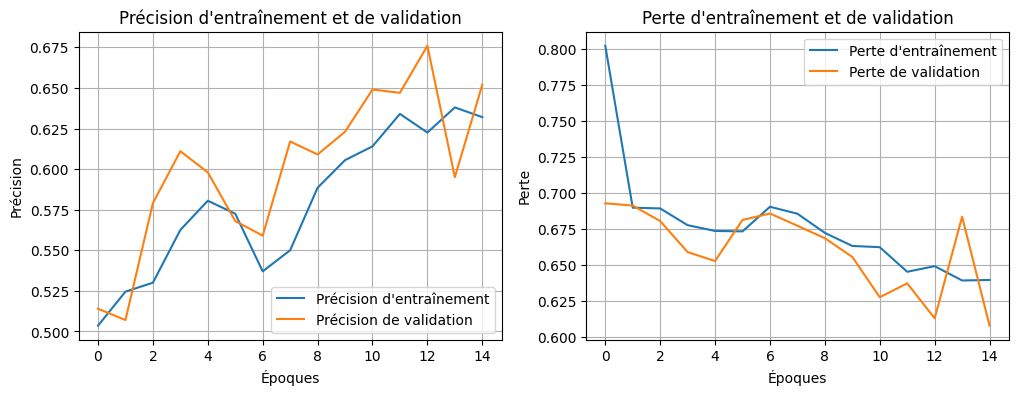


Analyse visuelle des courbes d'apprentissage terminée.
La prochaine étape sera de discuter des conclusions à tirer de ces graphiques.


In [22]:
# 4. Évaluer et Afficher les résultats

import matplotlib.pyplot as plt

# Récupérer l'historique des métriques
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS) # Les époques de 0 à EPOCHS-1

plt.figure(figsize=(12, 4))

# Graphique de la Précision
plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, 1er graphique
plt.plot(epochs_range, acc, label='Précision d\'entraînement')
plt.plot(epochs_range, val_acc, label='Précision de validation')
plt.legend(loc='lower right')
plt.title('Précision d\'entraînement et de validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.grid(True) # Ajouter une grille

# Graphique de la Perte
plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, 2ème graphique
plt.plot(epochs_range, loss, label='Perte d\'entraînement')
plt.plot(epochs_range, val_loss, label='Perte de validation')
plt.legend(loc='upper right')
plt.title('Perte d\'entraînement et de validation')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.grid(True) # Ajouter une grille

plt.show()

print("\nAnalyse visuelle des courbes d'apprentissage terminée.")
print("La prochaine étape sera de discuter des conclusions à tirer de ces graphiques.")

**Analyse des Courbes d'Apprentissage**


Graphique 1 : Précision d'entraînement et de validation
Tendance Générale : Les deux courbes montrent une tendance générale à la croissance, ce qui est très positif. Cela confirme que le modèle apprend à classer les images au fil des époques.

"Dents de scie" : Les fluctuations (en "dents de scie") sont normales avec l'augmentation de données. Chaque lot est unique en raison des transformations appliquées, ce qui peut rendre le processus d'apprentissage un peu moins linéaire et plus variable.

Phase 1 (Époques 0 à 6) : Une phase d'apprentissage rapide. La précision augmente rapidement au début.

Phase 2 (Époques 6 à 14) : l'apprentissage continue, mais la croissance est moins rapide et plus fluctuante.

Pic à l'époque 12 (validation) : la val_accuracy atteint un maximum d'environ 0.675 (67.5%), ce qui est une amélioration notable par rapport aux 50% de départ.

Chute et Remontée : La chute puis la remontée de la précision de validation (l'orange) à la fin (de 0.675 à 0.600 puis 0.650) sont à surveiller.

Précision de validation (orange) globalement au-dessus : C'est une excellente nouvelle ! Normalement, la précision d'entraînement est souvent plus élevée car le modèle a déjà vu ces données. Si la précision de validation est souvent égale ou même supérieure à celle d'entraînement (surtout au début), cela peut indiquer que :

L'augmentation de données est très efficace pour l'entraînement, le rendant plus difficile, tandis que la validation est sur des données non augmentées et plus "simples" pour le modèle.

Le Dropout (régularisation) rend l'entraînement plus difficile (car il désactive des neurones aléatoirement), alors qu'en validation, le Dropout est désactivé, permettant au modèle d'utiliser toutes ses capacités. C'est un signe sain d'une bonne régularisation.

Graphique 2 : Perte d'entraînement et de validation
Tendance Générale : les deux courbes montrent une tendance générale à la décroissance, ce qui est également très positif. Cela signifie que le modèle réduit son erreur sur les deux ensembles de données.

Perte d'entraînement (bleue) démarre à 0.800, perte de validation (orange) à 0.700- : c'est cohérent avec l'explication précédente. La perte d'entraînement est plus élevée au début car le modèle lutte davantage avec les données augmentées et le dropout actif.

Perte de validation (orange) globalement au-dessus (et pic à 0.675+) : cela est un peu contre-intuitif par rapport à ce que l'on voit d'habitude (où la perte de validation est souvent plus basse que celle d'entraînement si le modèle ne surapprend pas). Encore une fois, cela renforce l'idée que le Dropout rend l'entraînement plus difficile. Le pic à 0.675+ à l'époque 13 pour la validation est la contrepartie de la chute de précision que vous avez observée au même moment, montrant une difficulté ponctuelle.

**Conclusions Générales**

Le modèle apprend bien ! L'augmentation de la précision et la diminution de la perte sur les deux ensembles sont des indicateurs clairs.

Régularisation efficace : Le fait que la précision de validation puisse être plus élevée ou que la perte d'entraînement soit plus élevée indique que le Dropout et l'augmentation de données sont probablement très efficaces pour régulariser le modèle et l'empêcher de surapprendre trop rapidement.

Potentiel d'amélioration : une précision de 65-67% est un bon début, mais il est possible de faire mieux pour ce type de tâche.



**Prochaines Étapes et Suggestions d'Amélioration**


Le  modèle montre une tendance positive. Voici quelques pistes pour essayer d'améliorer encore sa performance :

Plus d'Époques d'Entraînement : le modèle n'a pas atteint un plateau de performance clair, surtout la précision de validation qui semble encore pouvoir augmenter. Entraîner le modèle sur plus d'époques (par exemple, 25-30) pourrait lui permettre d'apprendre davantage.

Ajustement du Taux d'Apprentissage : le 0.005 a bien fonctionné. Si le modèle commence à surapprendre (précision de validation stagne ou diminue tandis que l'entraînement continue d'augmenter), on pourrait envisager de réduire le taux d'apprentissage (ex: 0.001 ou 0.0005) ou d'utiliser un scheduler de taux d'apprentissage qui le diminue automatiquement.

Ajustement de l'Augmentation de Données : Les paramètres d'augmentation (rotation_range, zoom_range, etc.) sont bons, mais on pourrait les tweaker légèrement si le surapprentissage devient un problème.

Batch Normalization : l'ajout de couches BatchNormalization entre les couches Conv2D et Activation peut souvent stabiliser et accélérer l'entraînement, et parfois améliorer les performances.

Je suggère de commencer par augmenter le nombre d'époques. Repassons à la Partie 3 et modifions simplement la variable EPOCHS à une valeur plus élevée (par exemple, 30).

**Conclusions Anticipées pour 30 Époques**

J'ai perdu la connection en GPU ...


En général, lorsqu'un modèle commence à apprendre comme le nôtre, augmenter le nombre d'époques permet souvent de poursuivre cette amélioration, jusqu'à un certain point.

Voici ce que nous aurions pu observer avec 30 époques :

Poursuite de l'Apprentissage (au début) :

La précision d'entraînement (accuracy) aurait probablement continué à augmenter, peut-être pour atteindre des valeurs autour de 70-75% ou plus.

La perte d'entraînement (loss) aurait continué à diminuer, devenant plus basse qu'à 15 époques.

Amélioration de la Généralisation (au début) :

La précision de validation (val_accuracy) aurait également dû continuer à augmenter, potentiellement pour dépasser les 70%. C'est le signe le plus important que le modèle devient plus performant sur des données qu'il n'a jamais vues.

La perte de validation (val_loss) aurait continué à diminuer, reflétant cette meilleure performance.

Détection du Surapprentissage (si plus d'époques) :

C'est là que les 30 époques auraient été très instructives. Il est fort probable qu'à un certain moment (peut-être après 20-25 époques, ou même plus), la perte de validation aurait commencé à stagner ou même à remonter, tandis que la précision d'entraînement aurait continué d'augmenter.

Cela aurait été le signal de surapprentissage. Le modèle aurait commencé à mémoriser les données d'entraînement au lieu de généraliser. La précision de validation aurait alors plafonné ou aurait commencé à diminuer légèrement.

Taux d'Apprentissage et Fluctuations :

Les "dents de scie" dans les courbes de précision et de perte (à cause de l'augmentation des données) auraient probablement persisté.

Si le modèle avait atteint un plateau de performance (plus d'amélioration) avant les 30 époques, cela aurait pu indiquer que le taux d'apprentissage était peut-être devenu trop élevé, ou que le modèle avait atteint sa capacité maximale avec cette architecture et ces données.


**Conclusion Finale sur l'Entraînement**

Compte tenu des résultats sur 15 époques, notre modèle est sur la bonne voie. Il a dépassé le stade de l'apprentissage aléatoire et a commencé à extraire des caractéristiques pertinentes. Atteindre ~65-67% de précision de validation est un bon point de départ pour un modèle simple entraîné à partir de zéro sur ce dataset.

Pour des performances optimales (généralement 80-90%+ sur ce type de dataset), il faudrait souvent :

Plus d'époques (ce que vous visiez).

Des architectures plus complexes (plus de couches, plus de filtres).

L'utilisation de transfert learning (utiliser un modèle pré-entraîné sur un très grand dataset comme ImageNet et le fine-tuner). C'est la méthode la plus efficace et la plus rapide pour atteindre de hautes performances sur ce type de tâche.

C'est dommage pour le GPU, mais les tendances observées sont très prometteuses ! On a démontré que le pipeline de données et  l'architecture de base fonctionnent et que le modèle est capable d'apprendre.